In [23]:
#1 create a imbalanced dataset 
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter

x,y = make_classification(n_classes=2, n_samples=1000, n_features=20,weights=[0.09,0.01],random_state=30)
print("Original Distribution:",Counter(y))
df = pd.DataFrame(x)
df["target"]=y
df["target"].value_counts()

Original Distribution: Counter({np.int64(0): 541, np.int64(1): 459})


target
0    541
1    459
Name: count, dtype: int64

In [24]:
#apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=30)
x_res,y_res = smote.fit_resample(x,y)
print("Resampled Distribution:",Counter(y_res))

Resampled Distribution: Counter({np.int64(1): 541, np.int64(0): 541})


In [25]:
#train model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=30) #input output test_size random_state
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       119
           1       0.93      0.87      0.90        98

    accuracy                           0.91       217
   macro avg       0.92      0.91      0.91       217
weighted avg       0.91      0.91      0.91       217



In [26]:
model_weighted=LogisticRegression(
    class_weight='balanced',
    max_iter = 1000
)
model_weighted.fit(x_train,y_train)
y_pred_w = model_weighted.predict(x_test)

print(classification_report(y_test,y_pred_w))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       119
           1       0.93      0.87      0.90        98

    accuracy                           0.91       217
   macro avg       0.92      0.91      0.91       217
weighted avg       0.91      0.91      0.91       217



In [27]:
from sklearn.metrics import roc_auc_score, roc_curve,confusion_matrix
import matplotlib.pyplot as plt

probs = model_weighted.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,probs)
print("AUC:",auc)

AUC: 0.9685302692505573


In [28]:
import numpy as np 
threshold = 0.3
y_custom =(probs>threshold).astype(int)
print(classification_report(y_test,y_custom))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       119
           1       0.91      0.92      0.91        98

    accuracy                           0.92       217
   macro avg       0.92      0.92      0.92       217
weighted avg       0.92      0.92      0.92       217



In [29]:
x,y=make_classification(
    n_samples=6000,
    n_features=25,
    n_classes=2,
    n_informative =15,
    n_redundant=5,
    weights=[0.94,0.06],
    random_state=42,
    flip_y=0.02)
print("class Distribution:",pd.Series(y).value_counts())

class Distribution: 0    5584
1     416
Name: count, dtype: int64


In [31]:
x_train,x_test,y_train,y_test= train_test_split(
    x,y,
    test_size=0.3,
    stratify=y,
    random_state=42)

baseline_model= LogisticRegression(max_iter=1000)
baseline_model.fit(x_train,y_train)

y_pred_base=baseline_model.predict(x_test)

print("=======Baseline Model =======")
print(confusion_matrix(y_test,y_pred_base))
print(classification_report(y_test,y_pred_base))

=======Baseline Model =======
[[1668    7]
 [  84   41]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1675
           1       0.85      0.33      0.47       125

    accuracy                           0.95      1800
   macro avg       0.90      0.66      0.72      1800
weighted avg       0.95      0.95      0.94      1800



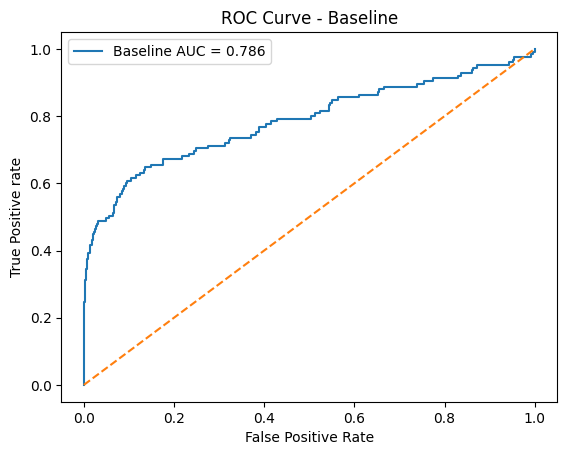

In [34]:
probs_base = baseline_model.predict_proba(x_test)[:,1]
fpr,tpr,_=roc_curve(y_test,probs_base)
auc_base=roc_auc_score(y_test,probs_base)
plt.plot(fpr,tpr,label=f"Baseline AUC = {auc_base:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive rate")
plt.title("ROC Curve - Baseline")
plt.legend()
plt.show()